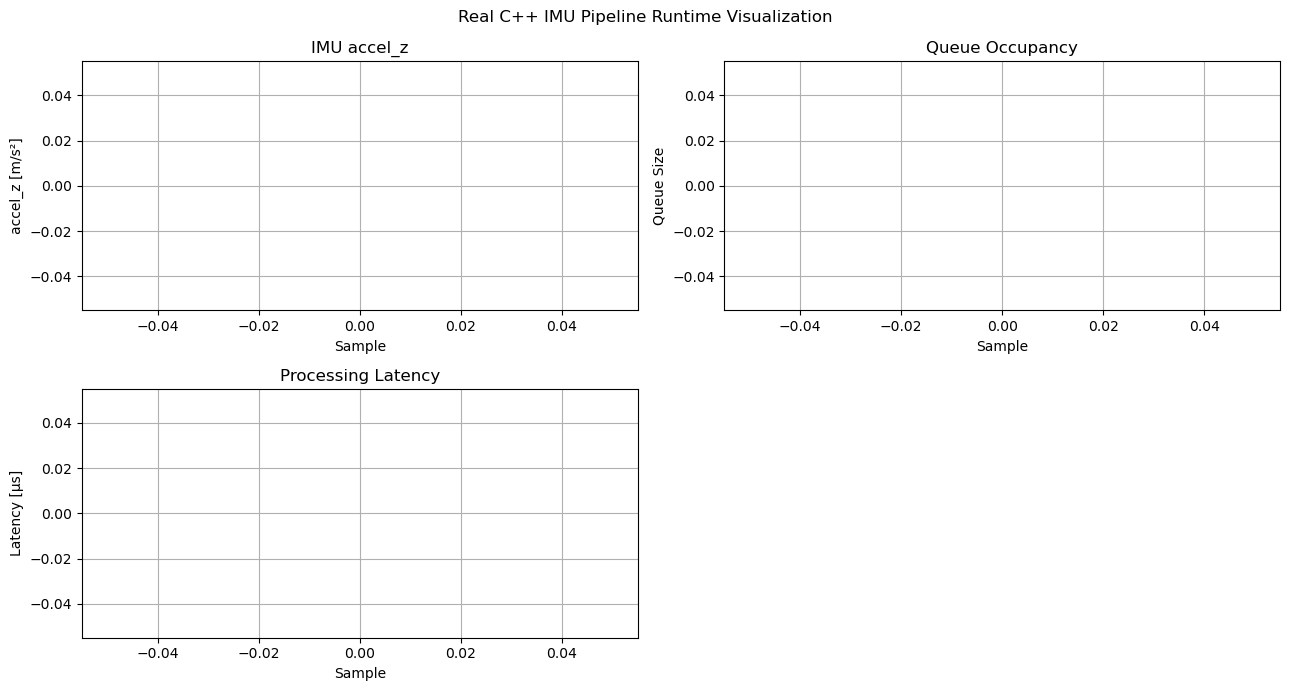

Saved animation as cpp_pipeline_animation.gif


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

df = pd.read_csv("pipeline_log.csv")

fig, axs = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Real C++ IMU Pipeline Runtime Visualization")

ax1, ax2, ax3, ax4 = axs.ravel()

line1, = ax1.plot([], [], lw=2)
line2, = ax2.plot([], [], lw=2)
line3, = ax3.plot([], [], lw=2)

ax1.set_title("IMU accel_z")
ax2.set_title("Queue Occupancy")
ax3.set_title("Processing Latency")

ax1.set_xlabel("Sample")
ax2.set_xlabel("Sample")
ax3.set_xlabel("Sample")

ax1.set_ylabel("accel_z [m/s²]")
ax2.set_ylabel("Queue Size")
ax3.set_ylabel("Latency [µs]")

for ax in [ax1, ax2, ax3]:
    ax.grid(True)

ax4.axis("off")
status = ax4.text(0.05, 0.95, "", va="top", family="monospace", fontsize=12)

window = 200

def update(frame):
    start = max(0, frame - window)
    data = df.iloc[start:frame]

    x = data["sample_id"]

    line1.set_data(x, data["accel_z"])
    line2.set_data(x, data["queue_size"])
    line3.set_data(x, data["latency_us"])

    for ax in [ax1, ax2, ax3]:
        ax.set_xlim(x.min(), x.max() + 1)

    ax1.set_ylim(df["accel_z"].min() - 0.05, df["accel_z"].max() + 0.05)
    ax2.set_ylim(0, max(5, df["queue_size"].max() + 2))
    #ax3.set_ylim(0, max(100, df["latency_us"].max() + 20))
    ax3.set_ylim(0, df["latency_us"].quantile(0.95))
    row = df.iloc[frame - 1]
    status.set_text(
        f"Pipeline Status\n"
        f"----------------------\n"
        f"Sample ID       : {int(row.sample_id)}\n"
        f"accel_z         : {row.accel_z:.3f} m/s²\n"
        f"Queue size      : {int(row.queue_size)}\n"
        f"Latency         : {row.latency_us:.0f} µs\n"
        f"Processed count : {int(row.processed_count)}"
    )

    return line1, line2, line3, status

ani = FuncAnimation(
    fig,
    update,
    frames=range(2, len(df)),
    interval=50,
    blit=False,
    repeat=False
)
plt.tight_layout()

plt.show()

ani.save("cpp_pipeline_animation.gif", writer=PillowWriter(fps=20))

print("Saved animation as cpp_pipeline_animation.gif")